# 🛡️ ForgeShield
## Exploratory Data Analysis & Preprocessing

**Project:** AI-Based Industrial Safety and Predictive Risk Management System

This notebook presents the exploratory analysis and preprocessing pipeline used for the ForgeShield research prototype.

### Objectives
- Inspect the AI4I 2020 Predictive Maintenance dataset
- Understand feature distributions and class imbalance
- Identify relationships between machine variables and failure
- Apply the same preprocessing strategy used by the supervised learning pipeline
- Prepare leakage-safe data for machine-failure prediction

**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Task:** Binary machine-failure classification

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically find the ForgeShield project root
current_path = Path.cwd().resolve()

PROJECT_ROOT = None

for path in [current_path, *current_path.parents]:
    if (path / "data").is_dir() and (path / "src").is_dir():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the ForgeShield project root."
    )

DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Find CSV datasets
csv_files = list(DATA_DIR.rglob("*.csv"))

print(f"Project root: {PROJECT_ROOT}")
print(f"CSV files found: {len(csv_files)}")

# Find AI4I dataset
ai4i_candidates = [
    f for f in csv_files
    if "ai4i" in f.name.lower()
    or "predictive" in f.name.lower()
]

if not ai4i_candidates:
    print("\nCSV files found:")
    for file in csv_files:
        print(" -", file.name)
    raise FileNotFoundError(
        "AI4I dataset was not found in data/raw/."
    )

DATA_PATH = ai4i_candidates[0]

df = pd.read_csv(DATA_PATH)

print(f"\nDataset: {DATA_PATH.name}")
print(f"Shape: {df.shape}")

Project root: /Users/aashiraghuvanshi/Documents/projects/ForgeShield
CSV files found: 1

Dataset: ai4i2020.csv
Shape: (10000, 14)


In [3]:
# Basic dataset inspection

print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

First 5 rows:


,UID,Product ID,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UID                  10000 non-null  int64  
 1   Product ID           10000 non-null  str    
 2   Type                 10000 non-null  str    
 3   Air temperature      10000 non-null  float64
 4   Process temperature  10000 non-null  float64
 5   Rotational speed     10000 non-null  int64  
 6   Torque               10000 non-null  float64
 7   Tool wear            10000 non-null  int64  
 8   Machine failure      10000 non-null  int64  
 9   TWF                  10000 non-null  int64  
 10  HDF                  10000 non-null  int64  
 11  PWF                  10000 non-null  int64  
 12  OSF                  10000 non-null  int64  
 13  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 1.1 MB

Missing values:


,Missing Values
UID,0
Product ID,0
Type,0
Air temperature,0
Process temperature,0
Rotational speed,0
Torque,0
Tool wear,0
Machine failure,0
TWF,0



Duplicate rows: 0


,Count,Percentage
Machine failure,,
0,9661,96.61
1,339,3.39


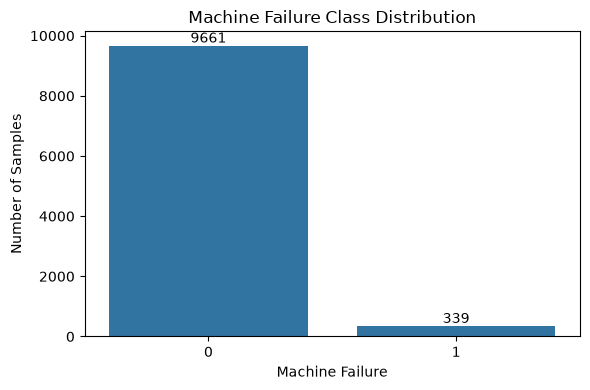

In [4]:
# Machine failure distribution

failure_counts = df["Machine failure"].value_counts().sort_index()
failure_percent = df["Machine failure"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "Count": failure_counts,
    "Percentage": failure_percent.round(2)
})

display(summary)

# Visualize class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Machine failure")

ax.set_title("Machine Failure Class Distribution")
ax.set_xlabel("Machine Failure")
ax.set_ylabel("Number of Samples")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [5]:
# Numerical feature summary

numeric_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

display(
    df[numeric_features]
    .describe()
    .T
    .round(3)
)

,count,mean,std,min,25%,50%,75%,max
Air temperature,10000.0,300.005,2.000,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,310.006,1.484,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,1538.776,179.284,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,39.987,9.969,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,107.951,63.654,0.0,53.0,108.0,162.0,253.0


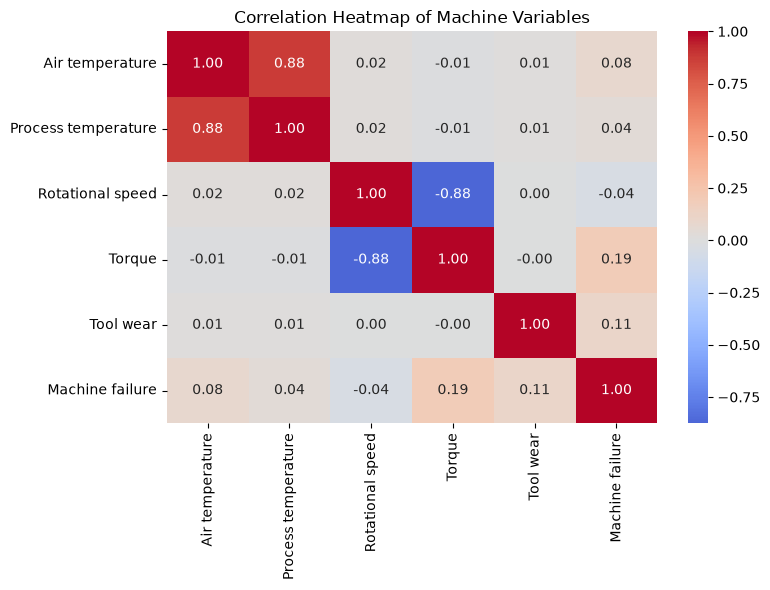

In [10]:
# Correlation analysis of numerical machine features

correlation = df[numeric_features + ["Machine failure"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Machine Variables")
plt.tight_layout()
plt.show()

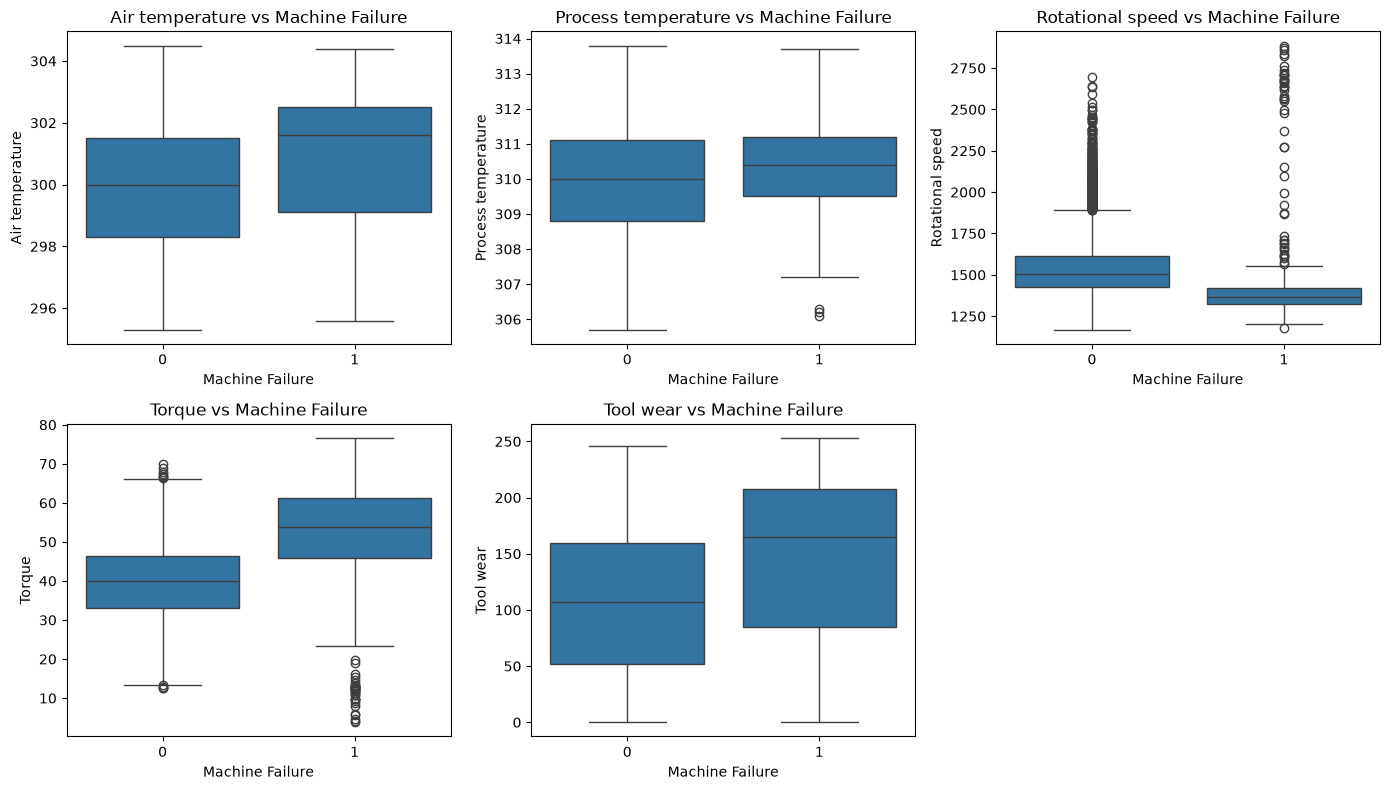

In [11]:
# Compare sensor distributions by machine-failure status

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature,
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} vs Machine Failure")
    axes[i].set_xlabel("Machine Failure")

# Remove unused sixth subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

,Number of Cases
HDF,115
OSF,98
PWF,95
TWF,46
RNF,19


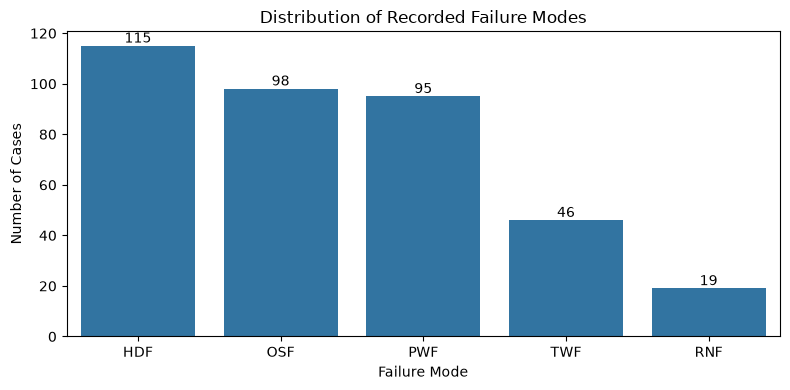

In [12]:
# Failure-mode analysis

failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_mode_counts = df[failure_modes].sum().sort_values(ascending=False)

display(
    failure_mode_counts
    .to_frame("Number of Cases")
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    x=failure_mode_counts.index,
    y=failure_mode_counts.values
)

ax.set_title("Distribution of Recorded Failure Modes")
ax.set_xlabel("Failure Mode")
ax.set_ylabel("Number of Cases")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [13]:
# Prepare features and target while preventing target leakage

target = "Machine failure"

identifier_columns = ["UID", "Product ID"]
failure_mode_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

leakage_columns = identifier_columns + failure_mode_columns

X = df.drop(columns=[target] + leakage_columns)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used:")
for column in X.columns:
    print(" -", column)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (10000, 6)
Target shape: (10000,)

Features used:
 - Type
 - Air temperature
 - Process temperature
 - Rotational speed
 - Torque
 - Tool wear

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [14]:
# Feature engineering

X = X.copy()

X["Temperature Differential"] = (
    X["Process temperature"] - X["Air temperature"]
)

X["Mechanical Power"] = (
    X["Rotational speed"]
    * X["Torque"]
    * (2 * np.pi / 60)
)

print("Features after engineering:")
for column in X.columns:
    print(" -", column)

print("\nFinal feature matrix shape:", X.shape)

Features after engineering:
 - Type
 - Air temperature
 - Process temperature
 - Rotational speed
 - Torque
 - Tool wear
 - Temperature Differential
 - Mechanical Power

Final feature matrix shape: (10000, 8)


In [15]:
# Stratified train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining failure rate:", round(y_train.mean() * 100, 2), "%")
print("Test failure rate:", round(y_test.mean() * 100, 2), "%")

Training set: (8000, 8)
Test set: (2000, 8)

Training failure rate: 3.39 %
Test failure rate: 3.4 %


In [16]:
# Leakage-safe preprocessing
# IQR clipping is learned from the training set only.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ["Type"]

numerical_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Temperature Differential",
    "Mechanical Power"
]

# Calculate IQR clipping bounds using training data only
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

clip_bounds = {}

for feature in numerical_features:
    q1 = X_train_processed[feature].quantile(0.25)
    q3 = X_train_processed[feature].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    clip_bounds[feature] = (lower, upper)

    X_train_processed[feature] = X_train_processed[feature].clip(lower, upper)
    X_test_processed[feature] = X_test_processed[feature].clip(lower, upper)

# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numerical", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train_ready = preprocessor.fit_transform(X_train_processed)
X_test_ready = preprocessor.transform(X_test_processed)

print("Preprocessing completed.")
print("Processed training shape:", X_train_ready.shape)
print("Processed test shape:", X_test_ready.shape)

Preprocessing completed.
Processed training shape: (8000, 10)
Processed test shape: (2000, 10)


## EDA & Preprocessing Summary

The AI4I 2020 dataset contains 10,000 observations with a strong class imbalance: **96.61% normal operation** and **3.39% machine-failure cases**.

The exploratory analysis identified notable relationships among the sensor variables, including strong correlations between air and process temperature and between rotational speed and torque. Boxplot analysis also showed distribution differences between normal and failure cases.

For modeling, identifier columns and the five failure-mode indicators were excluded to prevent target leakage. Two derived variables were added:

- **Temperature Differential** = Process Temperature − Air Temperature
- **Mechanical Power** = Rotational Speed × Torque × Angular Velocity

The data was divided using a **stratified 80/20 train-test split**. Missing values were handled through imputation, numerical outliers were clipped using training-set IQR bounds, categorical values were one-hot encoded, and numerical variables were standardized.

This preprocessing pipeline provides the leakage-controlled input used by the subsequent machine-failure prediction experiments.